# 🌌 Linear regression!

## 🗂️ Project structure

1. Following the task description, you'll find a set of formal requirements that your solution must meet.
2. The primary measure of your success is the **test** accuracy of your machine learning model.
3. After completing each task, you must answer a series of questions, marked with ❓, to demonstrate your understanding of the techniques used.
4. You may create as many cells as needed, but the final results should be kept in a short and simple cell

## 🧪 A note on test data

In a departure from real-world scenarios, you will have access to the target variables of the test sets for each task. This has been arranged to facilitate the evaluation of your models. However, remember that in actual machine learning projects, test targets are not available, as predicting these is the ultimate goal of your supervised models.

## 📝 Submission guidelines

- For each problem, provide your code solution and model results inside **problem.ipynb** and **linear_models.py**.
- Answer the follow-up questions in markdown format within this notebook. A few sentences is enough, no requirements for length of answers.
- Ensure your explanations are clear, concise, and demonstrate a deep understanding of the techniques employed.
- Submit **problem.ipynb** and **linear_models.py** to Canvas. Deliever the notebook such that outputs are saved, ideally *restart* the kernel followed by *run all*.

Good luck!

---

## 🔋 Problem 1: Predicting power consumption

### ❗️ The problem

You must develop a predictive model to estimate **power consumption** based on **network activity**.
️
Use `LinearRegression` class from `linear_models.py` stored in this folder. Your task is to complete two functions: `fit` (find the optimal parameters of the regression) and `predict` (apply them to the test data).

### 📋 Formal requirements
1. **Implementation**: 
   - Use standard Python libraries (numpy, math, pandas, etc.)
   - Implement `LinearRegression` class from `linear_models.py` from scratch
   - Optimize weights and bias with gradient descent from scratch

2. **Discussion**:
   - Visualize the training loss curve. Is it stable?
   - Visualize the fitted curve and derive the resulting Energy consumption formula.
   - Analyze the prediction error distribution. What is an unbiased estimator?
   - What does it tell you when the gradient in SGD is close to zero?

In [5]:
# The `%autoreload` IPython magic command allows instant updates from `linear_models.py`.
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from linear_models import LinearRegression, LogisticRegression  # <--- You will implement this

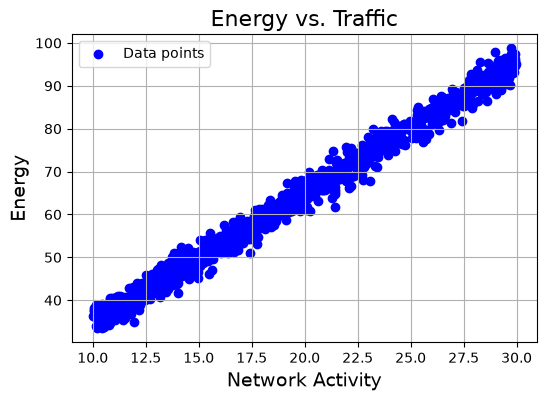

In [7]:
# Load data
data = pd.read_csv('regression.csv')

# Plot the data
plt.figure(figsize=(6, 4))
plt.scatter(data['Net_Activity'], data['Energy'], c='blue', label='Data points')
plt.grid(True)
plt.xlabel('Network Activity', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.title('Energy vs. Traffic', fontsize=16)
plt.legend()
plt.show()

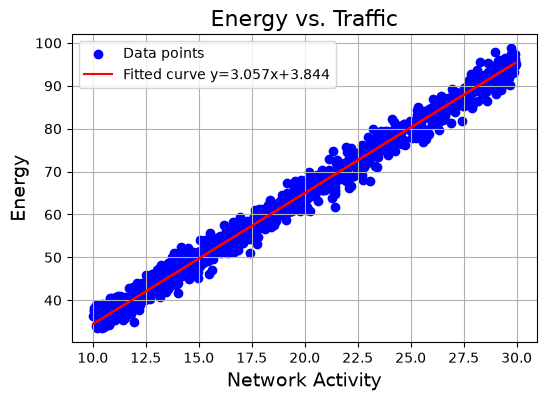

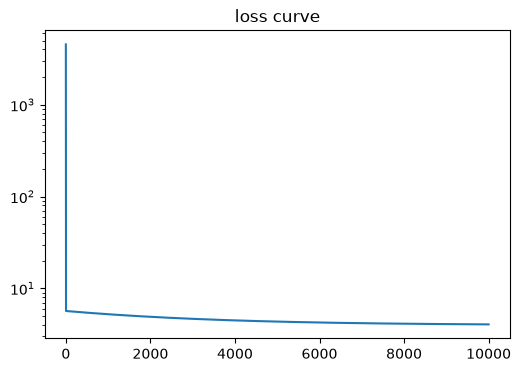

[np.float64(4545.156773768433), np.float64(82.79799563705522), np.float64(6.975868983955557), np.float64(5.687041596186449), np.float64(5.6646377672417385), np.float64(5.6637523712399584), np.float64(5.663232755487543), np.float64(5.662719507236472), np.float64(5.662206519523128), np.float64(5.66169368853579), np.float64(5.661181012464532), np.float64(5.66066849123264), np.float64(5.660156124792819), np.float64(5.659643913098333), np.float64(5.659131856102429), np.float64(5.658619953758392), np.float64(5.658108206019511), np.float64(5.657596612839094), np.float64(5.657085174170459), np.float64(5.656573889966933), np.float64(5.65606276018188), np.float64(5.655551784768666), np.float64(5.655040963680638), np.float64(5.6545302968712186), np.float64(5.654019784293794), np.float64(5.653509425901788), np.float64(5.652999221648639), np.float64(5.652489171487777), np.float64(5.651979275372674), np.float64(5.6514695332568206), np.float64(5.650959945093678), np.float64(5.650450510836752), np.flo

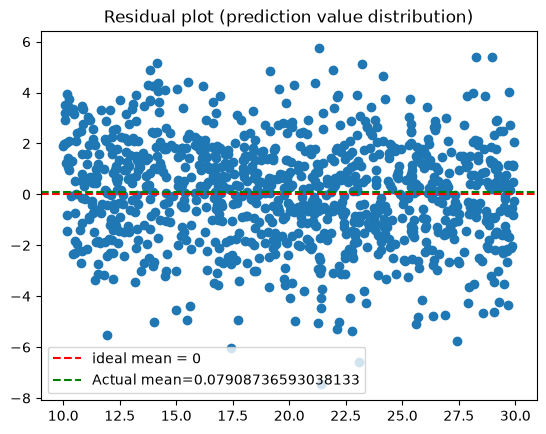

In [4]:
# ====================================
# YOUR CODE GOES HERE
# ====================================

X = data['Net_Activity'].to_numpy()
y = data['Energy'].to_numpy()
model = LinearRegression()
model.fit(X,y)
predictions = model.predict(X)
plt.figure(figsize=(6, 4))
plt.scatter(data['Net_Activity'], data['Energy'], c='blue', label='Data points')
plt.grid(True)
plt.xlabel('Network Activity', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.title('Energy vs. Traffic', fontsize=16)
plt.plot(X,predictions,c='r', label = f'Fitted curve y={round(model.weights, 3)}x+{round(model.bias,3)}')
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(model.loss_history)
plt.title('loss curve')
plt.yscale('log')
plt.show()
print(model.loss_history)

plt.scatter(X, model.pred_err)
plt.axhline(y=0, c='r',linestyle = '--',label='ideal mean = 0')
plt.axhline(y=np.mean(model.pred_err), c='g',linestyle='--',label=f'Actual mean={np.mean(model.pred_err)}')
plt.legend()
plt.title('Residual plot (prediction value distribution)')
plt.show()


### ❓ Is the training loss curve stable?
Indeed it is. it has a huge drop at first and then converges nicely. Just like you want it. 

### ❓ Derive the resulting energy consumption formula
This is in the plot legend.
### ❓ Analyze prediction error distribution. What is an unbiased estimator?
As we can see in the residual plot, the mean of the prediction error is close to zero. This is what you want, because it should be close to the excpected value of zero. The scattering has no clear pattern, so this clearly shows it is close to normally distributed, which is excactly what you want. I had to increase the epochs to 10 000 to make the bias converge better. 
### ❓ What does it tell you when the gradient in SGD is close to zero?
This tells you that the loss is minimized, either locally or globally. If the curve is convex, you have global minimum. If not, it could be a local. 

## 🔋 Problem 2: Logistic regression

### Your task
1. Implement logistic regression
2. Train your model on binary classification data
3. Engineer features to improve the model's performance

### Formal requirements
1. **Implementation**:
   - Same as before, use standard libraries
   - Implement gradient descent

2. **Performance**: Achieve at least **0.88** classification accuracy on the test set

3. **Discussion**:
   - Explain poor initial performance and your improvements
   - What is the model's inductive bias. Why is it important?
   - Plot the ROC curve, what does the area under the curve measure?

In [11]:
data = pd.read_csv('classification.csv')
train = data[data['split'] == 'train']
test = data[data['split'] == 'test']

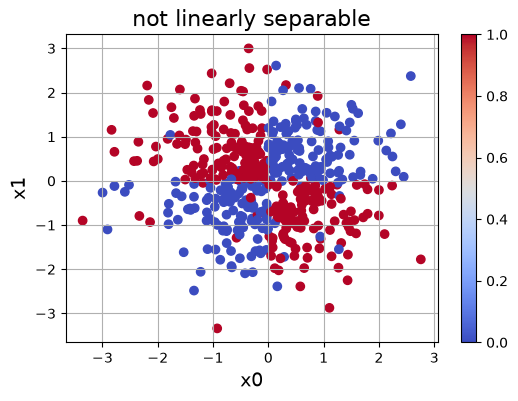

In [12]:
# visualize x0 and x1 of train on scatterplot with colors corresponding to y
plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('not linearly separable', fontsize=16)
plt.colorbar()
plt.show()

In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

In [ ]:
# ====================================
# YOUR CODE GOES HERE
# ====================================
def add_interaction(X):
    x0 = X[:,0]
    x1 = X[:,1]
    interaction = x0*x1
    return np.column_stack([x0,x1,interaction])

model = LogisticRegression(.3,1000)
X_train = add_interaction(train[["x0", "x1"]].to_numpy())
y_train = train["y"].to_numpy()

param_grid = {
    "lr":[1e-4, 1e-3, 1e-2, 1e-1,.5],
    "n_iterations":[1000,2000,5000,10000]
}
grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy"
)
grid.fit(X_train, y_train)
print(grid.best_params_,grid.best_score_)
model = grid.best_estimator_
X_test = add_interaction(test[["x0","x1"]].to_numpy())
y_test = test["y"].to_numpy()

y_scores = model.predict_proba(X_test)

def compute_roc(y_true, y_scores, n_thresholds=200):
    thresholds = np.linspace(1, 0, n_thresholds)  
    tpr_list = []
    fpr_list = []

    for thresh in thresholds:
        y_pred = (y_scores >= thresh).astype(int)

        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        tn = np.sum((y_pred == 0) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

        tpr_list.append(tpr)
        fpr_list.append(fpr)

    return np.array(fpr_list), np.array(tpr_list), thresholds
y_scores = model.predict_proba(X_test)
fpr, tpr, thresholds = compute_roc(y_test, y_scores)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(model.loss_history)
plt.title('loss curve')
plt.show()


print(f'accuracy: {model.accuracy(y_test, model.predict(X_test))}')

AttributeError: The following error was raised: 'LogisticRegression' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order.

### ❓ Explain poor initial performance and your improvements
There were two causes contributing to poor initial performance. First of all, the data itself is not linearly seperable. No linear model will be able to seperate the data when it is spread almost perfectly in the quadrants like we see in the x0x1 plot. However, we notice a clear pattern. When x1 and x0 have opposite signs, y values are mostly 0, and when they have the same sign, y values are mostly 1. We can utilize this by simply adding x0*x1 as a feature, and this is excactly what I did in the add feature function. This shot my accuracy up from about .5 to .9. This could probably also have been solved by not using a linear model. 
The other issue I had was with the pre-initialized values for learning rate. A learning rate of .0001 converged way too slowly. I found that using a learning rate of about .3 gave good convergence. 
### ❓ What is the model's inductive bias? Why is it important?
The inductive bias of this model is the x0*x1 relationship. This is important because it enables the model to pick up an actual pattern in the data instead of just guessing equivalently to a coin toss, or even worse. 

### ❓ What does the area under the ROC curve measure?
The accuracy of the model.